# 03 - Random Forest + Tuning iperparametri

**Obiettivo**:
1. Addestrare una Random Forest sul dataset PE-malware
2. Eseguire il **tuning** di `n_estimators`
3. Salvare il modello migliore in `rf_best_model.pkl` per la demo dello script `predict_real_file.py`
4. Calcolare matrice di confusione e metriche finali

**Domande di ricerca**:
- *Quanti alberi servono davvero nella Random Forest?*
- *Quanto migliora rispetto al Decision Tree singolo?*
---

## 1. Import delle librerie

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
os.makedirs('../output', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print('Librerie caricate correttamente')

Librerie caricate correttamente


## 2. Caricamento e split del dataset

Stessa procedura dei notebook precedenti: rimuovo `Name` e `Malware`, split 80/20 stratificato con `random_state=0`.

In [12]:
df = pd.read_csv('../dataset/dataset_malwares.csv')

X = df.drop(columns=['Name', 'Malware'])
y = df['Malware']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print(f'Train: {X_train.shape[0]:,} campioni, {X_train.shape[1]} feature')
print(f'Test : {X_test.shape[0]:,} campioni')

Train: 15,688 campioni, 77 feature
Test : 3,923 campioni


## 3. Random Forest baseline (n_estimators=100)

Prima alleno una RF con valori di default per avere un riferimento immediato confrontabile col Decision Tree del notebook 02.

In [13]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

acc_base  = accuracy_score (y_test, y_pred_base) * 100
prec_base = precision_score(y_test, y_pred_base) * 100
rec_base  = recall_score   (y_test, y_pred_base) * 100
f1_base   = f1_score       (y_test, y_pred_base) * 100

print(f'Random Forest baseline (n_estimators=100):')
print(f'   Accuracy : {acc_base:.2f}%')
print(f'   Precision: {prec_base:.2f}%')
print(f'   Recall   : {rec_base:.2f}%')
print(f'   F1-score : {f1_base:.2f}%')
print(f'\nConfronto col Decision Tree (notebook 02): 98.57% accuracy')
print(f'Miglioramento RF vs DT: +{acc_base - 98.57:.2f} punti')

Random Forest baseline (n_estimators=100):
   Accuracy : 99.11%
   Precision: 99.08%
   Recall   : 99.73%
   F1-score : 99.40%

Confronto col Decision Tree (notebook 02): 98.57% accuracy
Miglioramento RF vs DT: +0.54 punti


## 4. Esperimento 3: tuning di n_estimators

**Domanda**: aumentare il numero di alberi migliora sempre l'accuracy?

Provo `n_estimators` da 50 a 500 misurando train e test accuracy. La differenza tra le due mi dà un indicatore di **overfitting**: train al 100% e test molto più basso ⇒ overfitting; train e test entrambi alti ⇒ il modello generalizza.

In [14]:
n_estimators_list = [50, 100, 200, 300, 400, 500]
train_acc, test_acc, fit_times = [], [], []

for n in n_estimators_list:
    t0 = time.time()
    rf = RandomForestClassifier(n_estimators=n, random_state=0, n_jobs=-1)
    rf.fit(X_train, y_train)
    elapsed = time.time() - t0

    tr = rf.score(X_train, y_train) * 100
    te = rf.score(X_test, y_test) * 100

    train_acc.append(tr)
    test_acc.append(te)
    fit_times.append(elapsed)

    print(f'n={n:4d}: train={tr:.3f}%, test={te:.3f}%, tempo={elapsed:.1f}s')

best_n = n_estimators_list[int(np.argmax(test_acc))]
print(f'\nMigliore n_estimators (sul test set): {best_n}')
print(f'Test accuracy massima: {max(test_acc):.3f}%')

n=  50: train=99.981%, test=99.006%, tempo=0.1s
n= 100: train=99.981%, test=99.108%, tempo=0.1s
n= 200: train=99.981%, test=99.108%, tempo=0.3s
n= 300: train=99.981%, test=99.108%, tempo=0.4s
n= 400: train=99.981%, test=99.108%, tempo=0.5s
n= 500: train=99.981%, test=99.057%, tempo=0.6s

Migliore n_estimators (sul test set): 100
Test accuracy massima: 99.108%


## 5. Grafico tuning n_estimators

Salvato: ../output/tuning_n_estimators.png


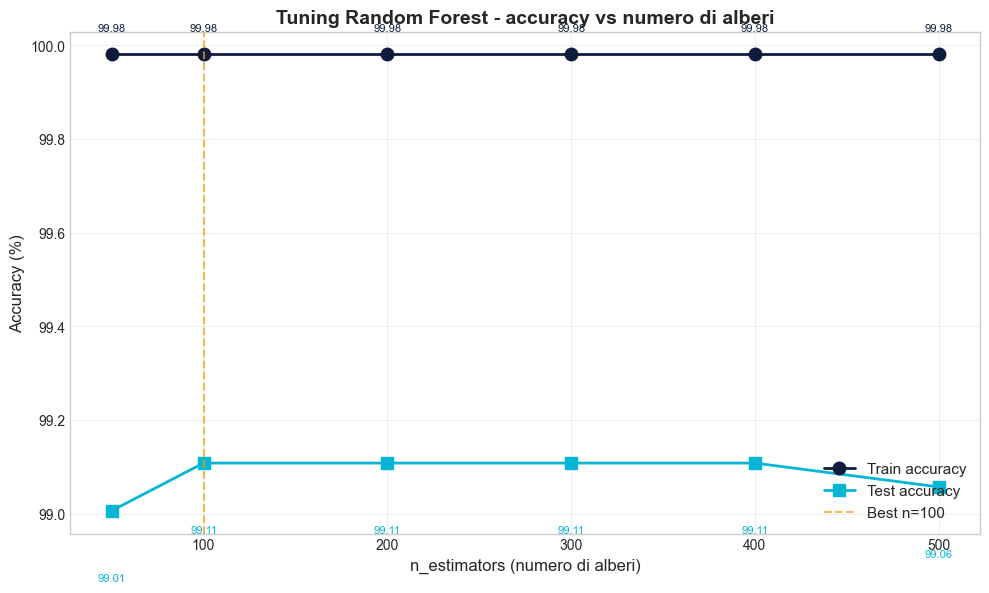

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

ax.plot(n_estimators_list, train_acc, marker='o', linewidth=2,
        label='Train accuracy', color='#0F1B3D', markersize=9)
ax.plot(n_estimators_list, test_acc,  marker='s', linewidth=2,
        label='Test accuracy',  color='#06B6D4', markersize=9)

# evidenzio il punto migliore
ax.axvline(best_n, color='#F59E0B', linestyle='--', alpha=0.7,
           label=f'Best n={best_n}')

for n, tr, te in zip(n_estimators_list, train_acc, test_acc):
    ax.text(n, tr + 0.05, f'{tr:.2f}', ha='center', fontsize=8, color='#0F1B3D')
    ax.text(n, te - 0.15, f'{te:.2f}', ha='center', fontsize=8, color='#06B6D4')

ax.set_xlabel('n_estimators (numero di alberi)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Tuning Random Forest - accuracy vs numero di alberi',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/tuning_n_estimators.png', dpi=150, bbox_inches='tight')
print('Salvato: ../output/tuning_n_estimators.png')
plt.show()

**Osservazione**: la train accuracy è sempre vicinissima al 100% (il modello apprende molto bene il training set), mentre la **test accuracy si stabilizza dopo n≈100**. Aggiungere più alberi oltre questo punto **non porta benefici significativi** ma aumenta linearmente il tempo di calcolo.

Questo è il classico comportamento di un ensemble: oltre una certa soglia, gli alberi aggiuntivi sono ridondanti.

## 6. Random Forest finale con n_estimators ottimo

Riaddestro il modello con il `best_n` trovato e calcolo le metriche finali.

In [16]:
rf_best = RandomForestClassifier(n_estimators=best_n, random_state=0, n_jobs=-1)
rf_best.fit(X_train, y_train)
y_pred = rf_best.predict(X_test)

acc  = accuracy_score (y_test, y_pred) * 100
prec = precision_score(y_test, y_pred) * 100
rec  = recall_score   (y_test, y_pred) * 100
f1   = f1_score       (y_test, y_pred) * 100

print(f'Random Forest TUNATA (n_estimators={best_n}):')
print(f'   Accuracy : {acc:.2f}%')
print(f'   Precision: {prec:.2f}%')
print(f'   Recall   : {rec:.2f}%')
print(f'   F1-score : {f1:.2f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Legit','Malware']))

Random Forest TUNATA (n_estimators=100):
   Accuracy : 99.11%
   Precision: 99.08%
   Recall   : 99.73%
   F1-score : 99.40%

              precision    recall  f1-score   support

       Legit       0.99      0.97      0.98      1003
     Malware       0.99      1.00      0.99      2920

    accuracy                           0.99      3923
   macro avg       0.99      0.99      0.99      3923
weighted avg       0.99      0.99      0.99      3923



## 7. Matrice di confusione finale

Le 4 quantità chiave: TP, FN, FP, TN. In un contesto di sicurezza i **falsi negativi (FN)** sono i più gravi: malware non riconosciuti.

Random Forest finale - matrice di confusione:
   TP (malware corretti) = 2,912
   FN (malware sfuggiti) = 8    <-- i più gravi in sicurezza
   FP (falsi allarmi)    = 27
   TN (legit corretti)   = 976

Totale test set: 3,923

Salvato: ../output/confusion_matrix_rf.png


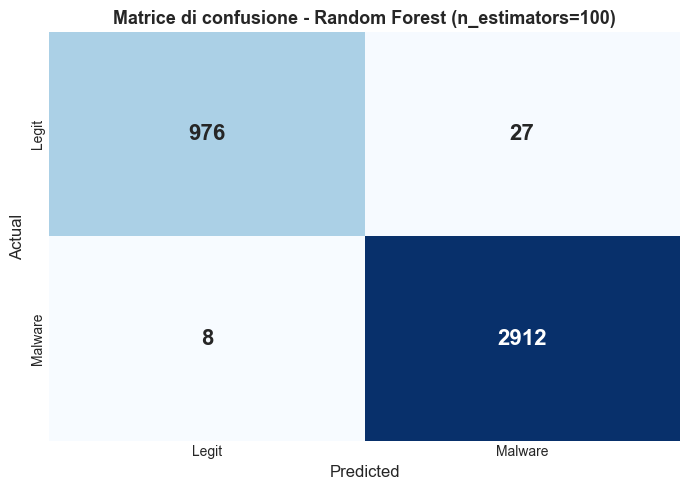

In [17]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print(f'Random Forest finale - matrice di confusione:')
print(f'   TP (malware corretti) = {TP:,}')
print(f'   FN (malware sfuggiti) = {FN:,}    <-- i più gravi in sicurezza')
print(f'   FP (falsi allarmi)    = {FP:,}')
print(f'   TN (legit corretti)   = {TN:,}')
print(f'\nTotale test set: {TN+FP+FN+TP:,}')

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legit', 'Malware'],
            yticklabels=['Legit', 'Malware'],
            annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title(f'Matrice di confusione - Random Forest (n_estimators={best_n})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('../output/confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
print('\nSalvato: ../output/confusion_matrix_rf.png')
plt.show()

## 8. Feature importance dalla Random Forest

Top 15 feature secondo Random Forest:
                    feature  importance
      MajorSubsystemVersion    0.090790
MinorOperatingSystemVersion    0.083016
MajorOperatingSystemVersion    0.082485
         SizeOfStackReserve    0.072683
              TimeDateStamp    0.065630
                  Subsystem    0.064376
          MinorImageVersion    0.060637
         MajorLinkerVersion    0.058522
      MinorSubsystemVersion    0.054977
                  ImageBase    0.033077
            Characteristics    0.028194
       DirectoryEntryExport    0.027914
         DllCharacteristics    0.023365
             SectionMaxChar    0.022890
      SizeOfInitializedData    0.022204

Notare: rispetto al singolo Decision Tree, la RF distribuisce
l'importanza su piu feature (effetto del bagging).

Salvato: ../output/feature_importance_rf.png


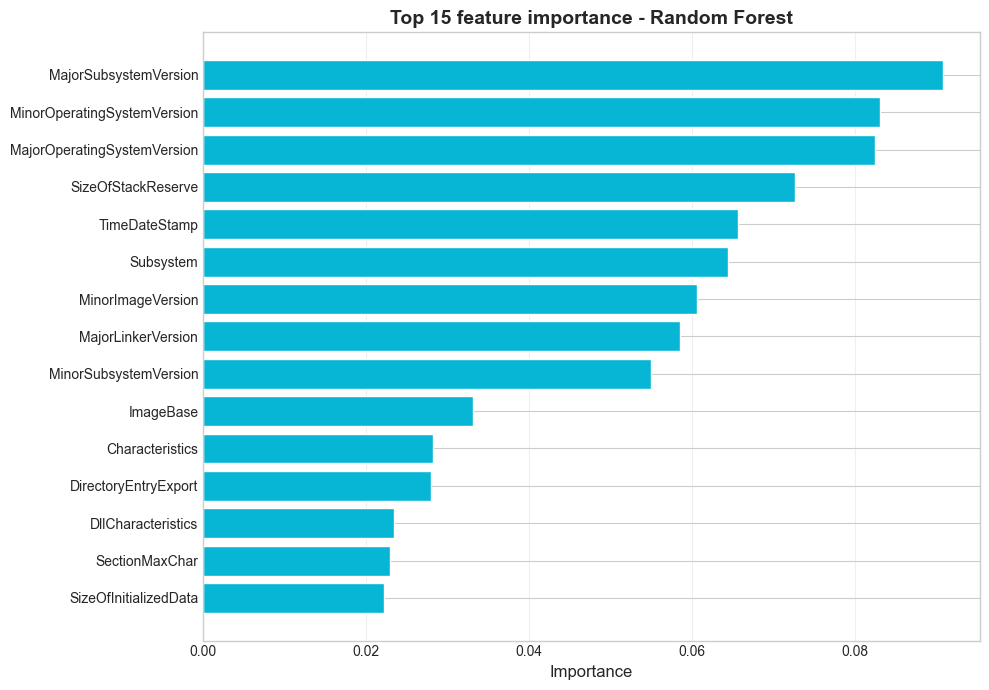

In [18]:
imp_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 15 feature secondo Random Forest:')
print(imp_df.head(15).to_string(index=False))
print(f'\nNotare: rispetto al singolo Decision Tree, la RF distribuisce')
print(f'l\'importanza su piu feature (effetto del bagging).')

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')
top15 = imp_df.head(15).iloc[::-1]
ax.barh(top15['feature'], top15['importance'], color='#06B6D4',
        edgecolor='white', linewidth=1)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 15 feature importance - Random Forest',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../output/feature_importance_rf.png', dpi=150, bbox_inches='tight')
print('\nSalvato: ../output/feature_importance_rf.png')
plt.show()

## 9. Salvataggio del modello

Salvo il modello tunato in formato pickle. Verra caricato dallo script `predict_real_file.py` per classificare file `.exe` reali

In [19]:
model_path = '../models/rf_best_model.pkl'
joblib.dump(rf_best, model_path)

size_mb = os.path.getsize(model_path) / 1024 / 1024
print(f'Modello salvato in: {model_path}')
print(f'Dimensione: {size_mb:.2f} MB')
print(f'\nPer caricarlo in altri script:')
print(f"   import joblib")
print(f"   model = joblib.load('{model_path}')")
print(f"   pred = model.predict(X_new)")

Modello salvato in: ../models/rf_best_model.pkl
Dimensione: 4.47 MB

Per caricarlo in altri script:
   import joblib
   model = joblib.load('../models/rf_best_model.pkl')
   pred = model.predict(X_new)


## 10. Riepilogo

In [20]:
print('=' * 70)
print('RIEPILOGO (tuning n_estimators)')
print('=' * 70)
print(f'{"n_estimators":>14} | {"Train acc":>10} | {"Test acc":>10}')
print('-' * 42)
for n, tr, te in zip(n_estimators_list, train_acc, test_acc):
    marker = '  <-- BEST' if n == best_n else ''
    print(f'{n:>14} | {tr:>9.3f}% | {te:>9.3f}%{marker}')

print()
print('=' * 70)
print('  RIEPILOGO (matrice di confusione finale)')
print('=' * 70)
print(f'Modello: Random Forest, n_estimators={best_n}')
print(f'TP={TP}, FN={FN}, FP={FP}, TN={TN}')
print(f'Accuracy={acc:.2f}%, Precision={prec:.2f}%, Recall={rec:.2f}%, F1={f1:.2f}%')
print('=' * 70)

RIEPILOGO (tuning n_estimators)
  n_estimators |  Train acc |   Test acc
------------------------------------------
            50 |    99.981% |    99.006%
           100 |    99.981% |    99.108%  <-- BEST
           200 |    99.981% |    99.108%
           300 |    99.981% |    99.108%
           400 |    99.981% |    99.108%
           500 |    99.981% |    99.057%

  RIEPILOGO (matrice di confusione finale)
Modello: Random Forest, n_estimators=100
TP=2912, FN=8, FP=27, TN=976
Accuracy=99.11%, Precision=99.08%, Recall=99.73%, F1=99.40%
